In [77]:
%load_ext autoreload
%autoreload 2
import sisl
import numpy as np
import matplotlib.pyplot as plt
from mytools.plots import thesis_fig
from scipy.spatial import cKDTree
from mytools.construct import all_armchair
from ase.visualize.plot import plot_atoms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
BOND = 1.42
phi = np.pi/3
B = BOND*np.cos(phi/2)

N0 = 4
N1 = 7
N2 = 12

R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

ETA = 1e-3
NUMK = 400

## To understand geometry of the hexagon structure see plot

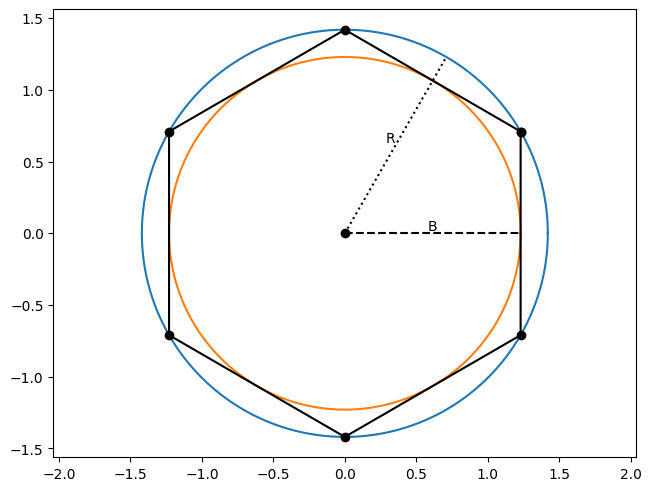

In [79]:
fig, ax = plt.subplots()
atoms = all_armchair(BOND)
atoms = atoms.translate(-atoms.center())
atoms = atoms.sub([3, 1, 0, 2, 4, 5, 3])
atoms = atoms.xyz[:, :2]
# print(atoms)
t = np.deg2rad(np.arange(0, 361, step=1))

outer_circ = np.array([np.cos(t)*BOND, np.sin(t)*BOND])
inner_circ = np.array([B*np.cos(t), B*np.sin(t)])
ax.plot(*outer_circ)
ax.plot(*inner_circ)
ax.plot(*atoms.T, color="k", linestyle="-", marker="o")
ax.plot([0, B], [0, 0], color="k", linestyle="--")
ax.scatter(0, 0, c="k", marker="o")
ax.text(B/2, 0, "B", verticalalignment="bottom", horizontalalignment="center")

ax.plot([0, BOND*np.cos(np.pi/3)], [0, BOND*np.sin(np.pi/3)], color="k", linestyle=":")
ax.text(BOND/2*np.cos(np.pi/3), BOND/2*np.sin(np.pi/3), "R", verticalalignment="bottom", horizontalalignment="right")

ax.axis("equal")
fig.set_constrained_layout(True)

## method for constructing edges of the unitcell
is also available in the `mytools.construct` module

In [80]:
def make_edge(geom, N0, N1):
    
    grev = geom.copy()
    grev.cell[0] = -geom.cell[0]
    grev.cell[1] = -geom.cell[1]
    grBottom = geom.tile(N0-1, 0)
    grRight = geom.tile(N1-1, 1).translate((N0-1)*geom.cell[0])
    grTop = grev.tile(N0-1, 0)\
        .translate((N1-1)*geom.cell[1])\
        .translate((N0-1)*geom.cell[0])
    grLeft = grev.tile(N1-1, 1).translate((N1-1)*geom.cell[1])
    grtot = grBottom + grRight + grTop + grLeft
    grtot.cell[0] = geom.cell[0]*N0
    grtot.cell[1] = geom.cell[1]*N1
    return grtot

In [81]:
graphene6 = all_armchair(BOND)

Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

In [82]:
edge, corner_idx = make_edge(graphene6, N0, N0), None
print(f"""total : {edge.na},
  1 edge : {graphene6.na*(N0 - 1)},
  2 edge : {graphene6.na*2*(N0 - 1)},
  3 edge : {graphene6.na*3*(N0 - 1)},
  4 edge : {graphene6.na*4*(N0 - 1)}""")

total : 72,
  1 edge : 18,
  2 edge : 36,
  3 edge : 54,
  4 edge : 72


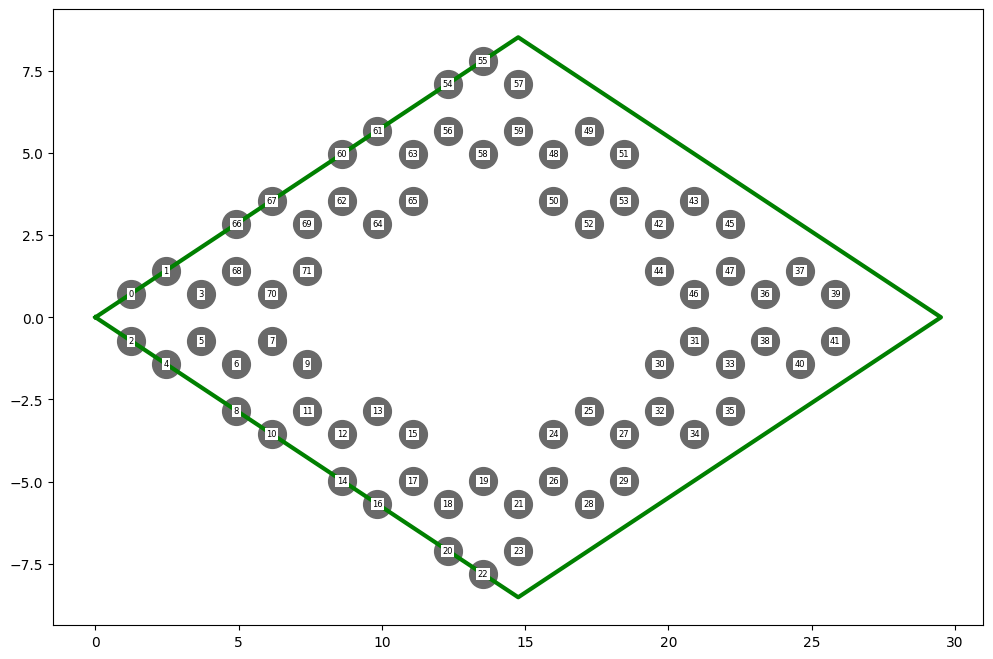

In [83]:

fig, ax = plt.subplots(figsize=(12,8))

# plot unit cell
A, B = edge.cell[:2, :2]
UC = np.array([0*A, A, A+B, B, 0*A])
ax.plot(*UC.T, color="g", lw=3)

coords = edge.xyz[:, :2]
ax.scatter(*coords.T, color="dimgrey", s=400)
for i in range(edge.na):
    x,y = coords[i]
    ax.text(x,y, s=i, fontsize=6, 
            verticalalignment="center", horizontalalignment="center",
            bbox=dict(facecolor="white", pad=1, edgecolor="none"),
                )

In [84]:
def plot_with_numbers(geom, ax=None, radii=None):
    from matplotlib import patches
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    plot_atoms(geom.to.ase(), ax=ax, radii=radii)
    circles = ax.findobj(match=patches.Circle)
    xminp, yminp = np.min(np.array([c.center for c in circles]), axis=0)
    dx = xminp - min(edge.xyz[:, 0])
    
    x,y = geom.xyz[:, :2].T
    xmin, ymin = min(x), min(y)
    dx, dy = xminp - xmin, yminp - ymin
    
    for i in range(geom.na):
        ax.text(x[i] + dx , y[i] + dy, str(i), fontsize=8,
                ha="center", va="center",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.1)
                )
    
    ax.set_aspect("equal")


# Make the edges and RSSE

In [85]:
rsse1 = sisl.RealSpaceSE(Ham0, 0, 1, (N1, N1, 1))
rsse1.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))

rsse2 = sisl.RealSpaceSE(Ham0, 0, 1, (N2, N2, 1))
rsse2.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))


In [86]:
Ham_rs_elec1, elec_idx1 = rsse1.real_space_coupling(ret_indices=True)
Ham_rs_elec2, elec_idx2 = rsse2.real_space_coupling(ret_indices=True)

In [87]:
g1edge = make_edge(graphene6, N1, N1)
g1 = Ham0.geometry.tile(N1, 0).tile(N1, 1)
g2edge = make_edge(graphene6, N2, N2)
g2 = Ham0.geometry.tile(N2, 0).tile(N2, 1)

g1rsse = g1.sub(elec_idx1)
g2rsse = g2.sub(elec_idx2)

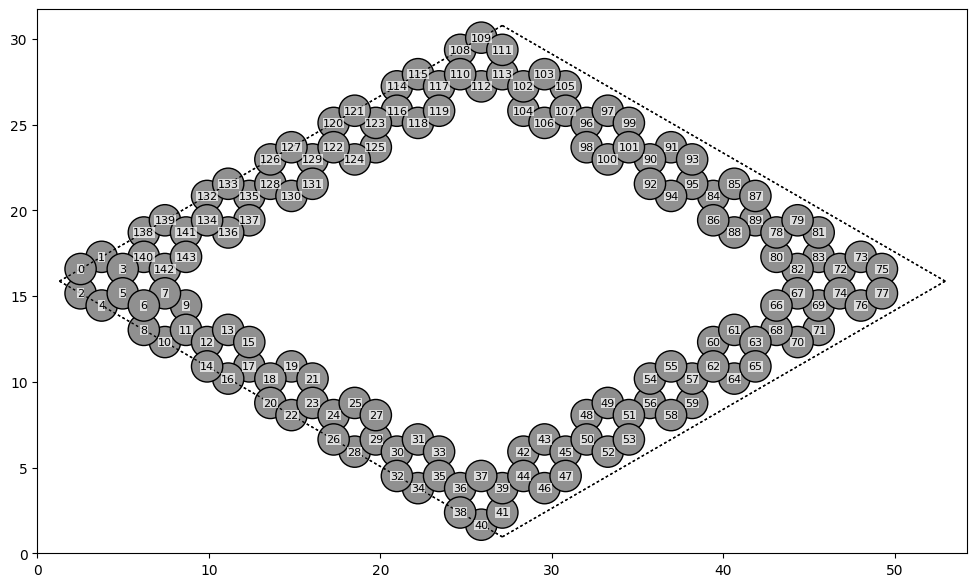

In [88]:
fig, ax = plt.subplots(figsize=(12,10))
plot_with_numbers(g1edge, ax=ax, radii=1.2)

In [89]:
def _tile_indices(n1: int, n2: int) -> tuple[int, int, int, int]:
    return 2*(n1+n2)-4, n1-1, n1+n2-2, 2*n1+n2-3

def get_corners(tile1, tile2=None, na=6, NC=1):
    if NC < 0:
        raise ValueError("## NC must be > 0")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(0, na*(NC + 1)), # bottom left hex + 1*NC
        range(na*(BR - NC), na*(BR + NC + 1)), # bottom right hex + 2*NC
        range(na*(TR - NC), na*(TR + NC + 1)), # top right hex + 2*NC
        range(na*(TL - NC), na*(TL + NC + 1)), # top left hex + 2*NC
        range(na*(BL - NC), na*BL) # bottom left 1*NC
    ]
    return np.concat(corners_atom_match)

def map_corners(tiles1, tiles2, na=6, NC=1):
    if not isinstance(tiles1, (tuple, list)):
        N1a, N1b = (tiles1, None)
    if not isinstance(tiles2, (tuple, list)):
        N2a, N2b = (tiles2, None)
    corners_match1 = get_corners(N1a, N1b, na, NC=NC)
    corners_match2 = get_corners(N2a, N2b, na, NC=NC)
    mapping = {}
    for i1, i2 in zip(corners_match1.flatten(), corners_match2.flatten()):
        mapping[int(i1)] = int(i2)
    return mapping

def get_edges(tile1, tile2, na=6, NC=1):
    if (NC < 0) or (2*NC > tile1-2) or (2*NC > tile2-2):
        raise ValueError("## NC must be > 0 and below (tile1-2)/2 and (tile2-2)/2")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        np.arange(na*(NC+1), na*(BR-NC)),
        np.arange(na*(BR+NC+1), na*(TR-NC)),
        np.arange(na*(TR+NC+1), na*(TL-NC)),
        np.arange(na*(TL+NC+1), na*(BL-NC)),
    ]
    return np.concat(corners_atom_match)

In [90]:
# corn = get_corners(N2, N2, NC=1)

In [91]:
g2edge.plot(axes="xy",
            atoms_style=[
                dict(atoms=get_corners(N2, N2, NC=1), color="red"),
                dict(atoms=get_edges(N2, N2, NC=1), color="lime")
            ])

In [92]:
NC = 1
na = Ham0.na
corners1 = get_corners(N1, N1, na=na, NC=NC)
corners2 = get_corners(N2, N2, na=na, NC=NC)
edges1 = get_edges(N1, N1, na=na, NC=NC)
edges2 = get_edges(N2, N2, na=na, NC=NC)

In [93]:
def get_centers(coords, na):
    rolling_mean = []
    for i in range(0, len(coords), na):
        roll = coords[i:i+na].mean(axis=0)
        rolling_mean.append(roll)
    return np.array(rolling_mean)


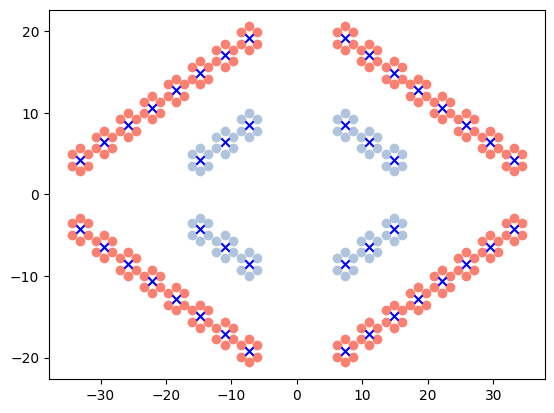

In [94]:
fig, ax = plt.subplots()

colors = ["lightsteelblue", "salmon"]
which = "edges"

for i, (geom, corn, ed) in enumerate(zip([g1edge.copy(), g2edge.copy()], 
                                         [corners1, corners2], 
                                         [edges1, edges2])):
    # geom = geom.copy()
    if which == "corners":
        xyz = geom.xyz[corn, :2]
    elif which == "edges":
        xyz = geom.xyz[ed, :2]
    elif which == "all":
        xyz = geom.xyz[:, :2]
    
    xyz -= geom.center()[:2]
    rolling_mean = get_centers(xyz, na=6)
    ax.scatter(*xyz[:, :2].T, color=colors[i])
    ax.scatter(*rolling_mean[:, :2].T, marker="x", color="blue")

In [95]:
cent1 = get_centers(g1edge.xyz[edges1], na=na)
cent2 = get_centers(g2edge.xyz[edges2], na=na)

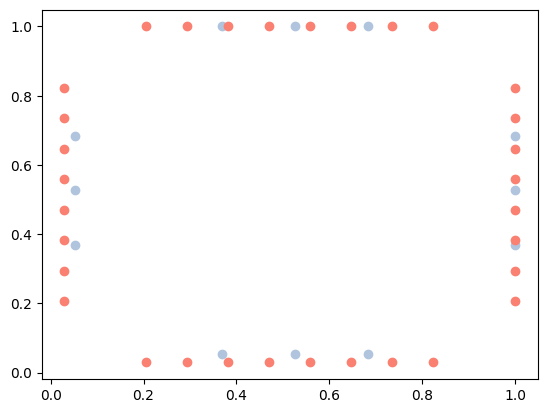

In [96]:
from mytools.scaling import get_fractional
coords = g1edge.copy().xyz[:, :2]
fig, ax = plt.subplots()
for i, (g, c) in enumerate(zip([g1edge, g2edge],
                             [cent1, cent2])):
    frac = get_fractional(g, c)
    ax.scatter(*frac.T, color=colors[i])

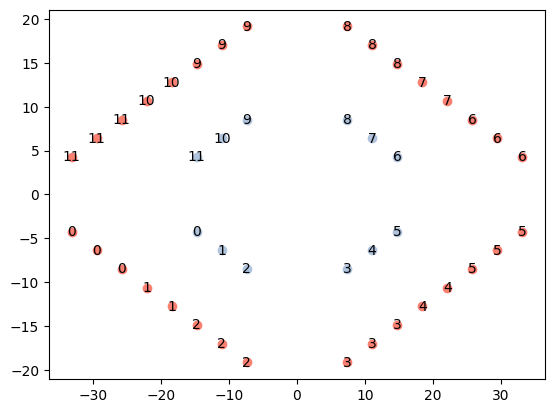

In [97]:
cent1_frac = get_fractional(g1edge, cent1)
cent2_frac = get_fractional(g2edge, cent2)
tree = cKDTree(cent1_frac)
dd, idx1_to_idx2 = tree.query(cent2_frac, k=1)

cent1_origo = cent1 - cent1.mean(axis=0)
cent2_origo = cent2 - cent2.mean(axis=0)

fig, ax = plt.subplots()
# plot atom centers for both
for i, c in enumerate([cent1_origo, cent2_origo]):
    ax.scatter(*c.T[:2], color=colors[i])

# plot 'center indicies' for geom 1
for i, (x,y,z) in enumerate(cent1_origo):
    ax.text(x,y, i, ha="center", va="center")

# plot 'center indicies' of geom 1 for geom 2
for i2, i1 in enumerate(idx1_to_idx2):
    x,y,_= cent2_origo[i2]
    ax.text(x, y, i1, ha="center", va="center")

In [98]:
tree = cKDTree(g2edge.xyz[:])
dd, center2_to_atoms2_idx = tree.query(cent2, k=na)
center2_to_atoms2_idx = np.sort(center2_to_atoms2_idx, axis=1)

In [99]:
tree = cKDTree(g1edge.xyz)
dd, center1_to_atoms1_idx = tree.query(cent1, k=na)
center1_to_atoms1_idx = np.sort(center1_to_atoms1_idx, axis=1)

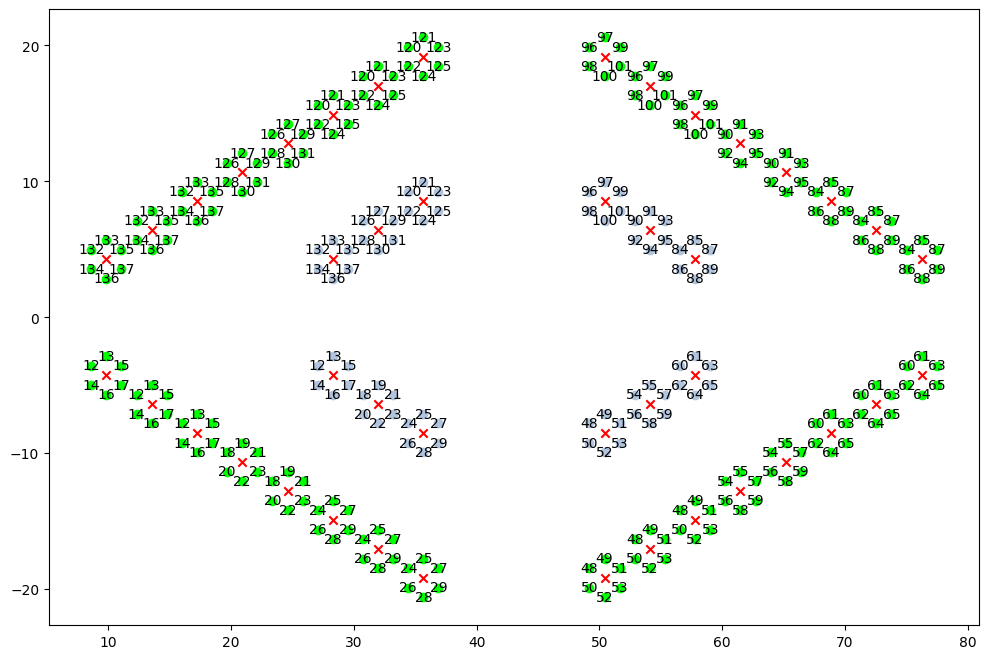

In [100]:

atoms = g2edge.xyz[edges2]
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(*atoms[:, :2].T, color="lime")
ax.scatter(*cent2[:, :2].T, color="r", marker="x")
for i2, i1 in enumerate(center1_to_atoms1_idx[idx1_to_idx2].flatten()):
    x_center, y_center, _ = atoms[i2]
    ax.text(x_center, y_center, i1, ha="center", va="center")


ax.scatter(*(g1edge.xyz[edges1, :2] - g1edge.center()[:2] + g2edge.center()[:2]).T, color="lightsteelblue")
ax.scatter(*(cent1- g1edge.center() + g2edge.center())[:, :2].T, color="r", marker="x")

for i, (x,y,_) in enumerate(g1edge.xyz[edges1] - g1edge.center() + g2edge.center()):
    ax.text(x, y, center1_to_atoms1_idx.flatten()[i], ha="center", va="center")

In [101]:
print("""
check :
    edges + corners = {}
    na = {}""".format(corners1.shape[0] + edges1.shape[0], g1edge.na))


check :
    edges + corners = 144
    na = 144


### validating if the indices are applied correctly

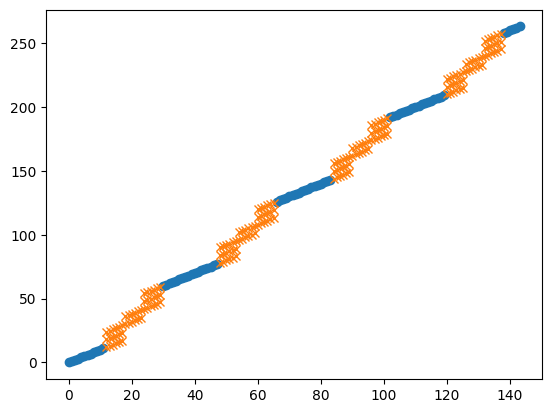

In [102]:
plt.plot(corners1, corners2, 'o'); 
plt.plot(edges1.reshape(-1, 6)[idx1_to_idx2].flatten(), edges2, 'x')

# Refractoring code

## Logic for finding corners, edges, and centroids

In [103]:
def _tile_indices(n1: int, n2: int) -> tuple[int, int, int, int]:
    return 2*(n1+n2)-4, n1-1, n1+n2-2, 2*n1+n2-3

def get_corners(tile1, tile2=None, na=6, NC=1):
    if NC < 0:
        raise ValueError("## NC must be > 0")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(0, na*(NC + 1)), # bottom left hex + 1*NC
        range(na*(BR - NC), na*(BR + NC + 1)), # bottom right hex + 2*NC
        range(na*(TR - NC), na*(TR + NC + 1)), # top right hex + 2*NC
        range(na*(TL - NC), na*(TL + NC + 1)), # top left hex + 2*NC
        range(na*(BL - NC), na*BL) # bottom left 1*NC
    ]
    return np.concat(corners_atom_match)

def map_corners(tiles1, tiles2, na=6, NC=1):
    if not isinstance(tiles1, (tuple, list)):
        N1a, N1b = (tiles1, None)
    if not isinstance(tiles2, (tuple, list)):
        N2a, N2b = (tiles2, None)
    corners_match1 = get_corners(N1a, N1b, na, NC=NC)
    corners_match2 = get_corners(N2a, N2b, na, NC=NC)
    mapping = {}
    for i1, i2 in zip(corners_match1.flatten(), corners_match2.flatten()):
        mapping[int(i1)] = int(i2)
    return mapping

def get_edges(tile1, tile2, na=6, NC=1):
    if (NC < 0) or (2*NC > tile1-2) or (2*NC > tile2-2):
        raise ValueError("## NC must be > 0 and below (tile1-2)/2 and (tile2-2)/2")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(na*(1+NC), na*(BR-NC)),
        range(na*(BR+NC+1), na*(TR-NC)),
        range(na*(TR+NC+1), na*(TL-NC)),
        range(na*(TL+NC+1), na*(BL-NC)),
    ]
    return np.concat(corners_atom_match)

def get_centers(coords, na):
    rolling_mean = []
    for i in range(0, len(coords), na):
        roll = coords[i:i+na].mean(axis=0)
        rolling_mean.append(roll)
    return np.array(rolling_mean)

### Testing previous logic

In [104]:
corners1 = get_corners(N1, N1, na=na, NC=NC)
corners2 = get_corners(N2, N2, na=na, NC=NC)
edges1 = get_edges(N1, N1, na=na, NC=NC)
edges2 = get_edges(N2, N2, na=na, NC=NC)

cent1 = get_centers(g1edge.xyz[edges1], na=na)
cent2 = get_centers(g2edge.xyz[edges2], na=na)

cent1_frac = get_fractional(g1edge, cent1)
cent2_frac = get_fractional(g2edge, cent2)
tree = cKDTree(cent1_frac)
dd, idx1_to_idx2 = tree.query(cent2_frac, k=1)

tree = cKDTree(g2edge.xyz[:])
dd, center2_to_atoms2_idx = tree.query(cent2, k=na)
center2_to_atoms2_idx = np.sort(center2_to_atoms2_idx, axis=1)

tree = cKDTree(g1edge.xyz)
dd, center1_to_atoms1_idx = tree.query(cent1, k=na)
center1_to_atoms1_idx = np.sort(center1_to_atoms1_idx, axis=1)

In [105]:
print(edges1.reshape(-1, na), edges1.reshape(-1, na).shape)
print()
print(idx1_to_idx2, idx1_to_idx2.shape)

[[ 12  13  14  15  16  17]
 [ 18  19  20  21  22  23]
 [ 24  25  26  27  28  29]
 [ 48  49  50  51  52  53]
 [ 54  55  56  57  58  59]
 [ 60  61  62  63  64  65]
 [ 84  85  86  87  88  89]
 [ 90  91  92  93  94  95]
 [ 96  97  98  99 100 101]
 [120 121 122 123 124 125]
 [126 127 128 129 130 131]
 [132 133 134 135 136 137]] (12, 6)

[ 0  0  0  1  1  2  2  2  3  3  3  4  4  5  5  5  6  6  6  7  7  8  8  8
  9  9  9 10 10 11 11 11] (32,)


#### Check for uneccesary recomputation
Using `center1_to_atoms1_idx` is equivalent to using `edges1`, but to avoid wrong sorting of indices, and reduced computations, we use the latter

In [106]:
(
    center1_to_atoms1_idx[idx1_to_idx2] == edges1.reshape(-1, 6)[idx1_to_idx2]
).all()


np.True_

## Refractoring code into one easy to use structure

In [107]:
def map_edges(g1, g2, tiles1, tiles2, na=6, NC=1):
    if isinstance(tiles1, (tuple, list)):
        N1a, N1b = tiles1
    else:
        N1a = N1b = tiles1
    
    if isinstance(tiles2, (tuple, list)):
        N2a, N2b = tiles2
    else:
        N2a = N2b = tiles2
        
    
    # get centroids
    edges1 = get_edges(N1a, N1b, na, NC)
    edges2 = get_edges(N2a, N2b, na, NC)
    cent1 = get_centers(g1.xyz[edges1], na)
    cent2 = get_centers(g2.xyz[edges2], na)
    
    # get fractional centroids
    cent1_frac = get_fractional(g1, cent1)
    cent2_frac = get_fractional(g2, cent2)
    
    tree = cKDTree(cent1_frac)
    _, edge_idx1_to_idx2 = tree.query(cent2_frac, k=1)
    return edges1.reshape(-1, na), edge_idx1_to_idx2

def _splitter(arr, diff_tol):
    diff = np.diff(arr)
    split_idx = np.where(np.abs(diff) >= diff_tol)[0] + 1
    parts = np.split(arr, split_idx)
    return parts

def extrapolate(g1, g2, tiles1, tiles2, na=6, NC=1):
    if isinstance(tiles1, (tuple, list)):
        N1a, N1b = tiles1
    else:
        N1a = N1b = tiles1
        
    # get edges and conversion of idx1 to idx2
    edges1, edge_idx1_to_idx2 = map_edges(g1, g2, tiles1, tiles2, na, NC)
    
    # get corners
    corners1 = get_corners(N1a, N1b, na, NC)
    corner_parts = _splitter(corners1, na)
    
    edge1_to_edges2 = edges1[edge_idx1_to_idx2]
    edge_parts = _splitter(edge1_to_edges2.flatten(), na)
    
    
    # append to final list
    g1_to_g2_idx = np.concat([
            corner_parts[0],
            edge_parts[0],
            corner_parts[1],
            edge_parts[1],
            corner_parts[2],
            edge_parts[2],
            corner_parts[3],
            edge_parts[3],
            corner_parts[4],
        ])
    return g1_to_g2_idx

### Testing if the refractored code works

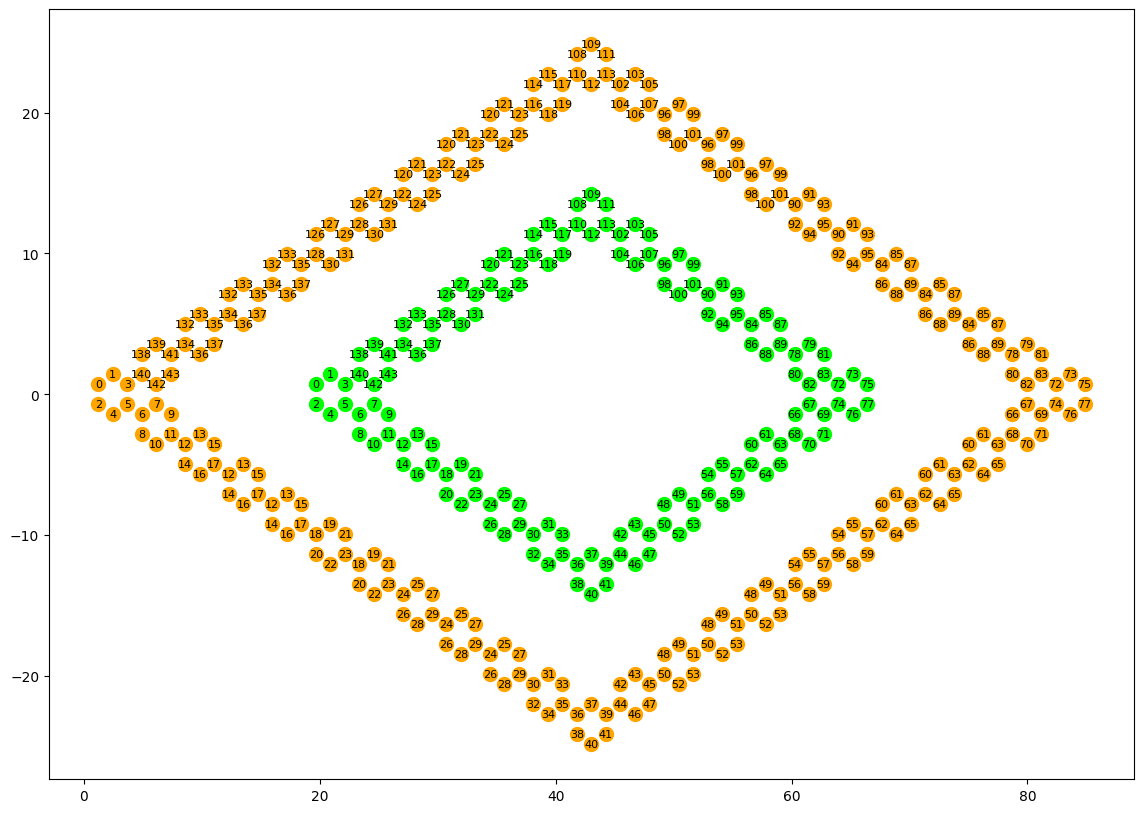

In [109]:
fig, ax = plt.subplots(figsize=(14,10))

ax.scatter(*g2edge.xyz.T[:2], s=100, c="orange")
g1_to_g2 = extrapolate(g1edge, g2edge, N1, N2, Ham0.na, NC=1)
# print(g1_to_g2)
for i2, i1 in enumerate(g1_to_g2):
    x,y,_ = g2edge.xyz[i2]
    ax.text(x,y,i1, ha="center", va="center", fontsize=8)


recenter = g1edge.copy().xyz
recenter += g2edge.center() - g1edge.center()
ax.scatter(*recenter.T[:2], s=100, c="lime")
for i1 in range(len(recenter)):
    x,y,_ = recenter[i1]
    ax.text(x,y,i1, ha="center", va="center", fontsize=8)

# Apply logic to scale RSSE

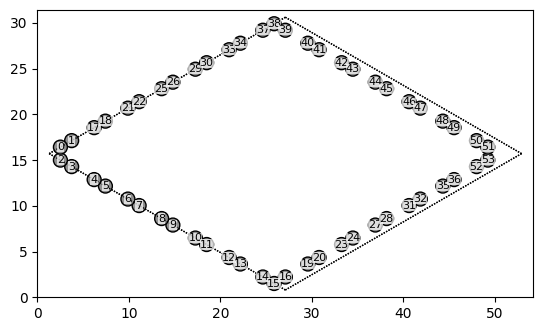

In [209]:
E = 0.1
z = E + ETA*1j

plot_with_numbers(Ham_rs_elec1.geometry)

## THis does not work using existing logic
# extrapolate(Ham_rs_elec1.geometry, Ham_rs_elec2.geometry, N1, N2, Ham0.na, NC=1)

Text(0.5, 0.98, 'RSSE 1 to edge 1')

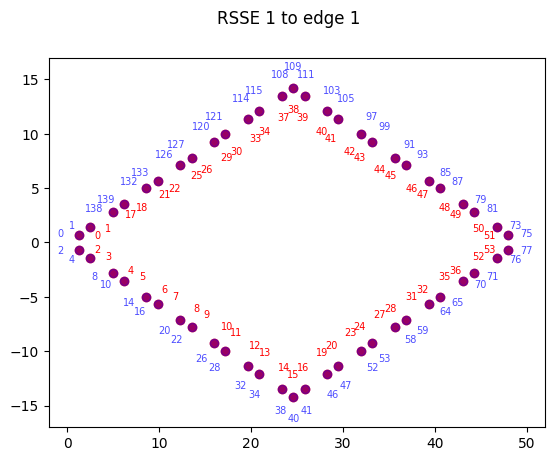

In [176]:
tol = 1e-4
rsse1_xyz = Ham_rs_elec1.xyz


tree = cKDTree(g1edge.xyz)
dd, ii = tree.query(rsse1_xyz, k=1)
fig, ax = plt.subplots()

ax.scatter(*rsse1_xyz.T[:2], c='r')
ax.scatter(*g1edge.xyz[ii, :2].T, alpha=0.4, c='b')

# Compute structure center in xy
center = g1edge.center()[:2]

offset_scale = 2 # Å — tune this

for i, rsseidx in enumerate(ii):
    x_rsse, y_rsse, _ = rsse1_xyz[i]
    x_edge, y_edge, _ = g1edge.xyz[rsseidx]

    # Outward unit normal: direction from center to atom
    outward = np.array([x_edge, y_edge]) - center
    outward /= np.linalg.norm(outward)  # unit vector

    # RSSE index: nudge inward (toward center)
    dx_in, dy_in = -outward * offset_scale
    ax.text(x_rsse + dx_in, y_rsse + dy_in, i,
            ha="center", va="center", color='r', fontsize=7)

    # Edge index: nudge outward (away from center)
    dx_out, dy_out = outward * offset_scale
    ax.text(x_edge + dx_out, y_edge + dy_out, rsseidx,
            ha="center", va="center", color='b', fontsize=7, alpha=0.7)


ax.set(xlim=(-2, 52),
       ylim=(-17, 17),)
    
fig.suptitle("RSSE 1 to edge 1")

Text(0.5, 0.98, 'RSSE 2 to edge 2')

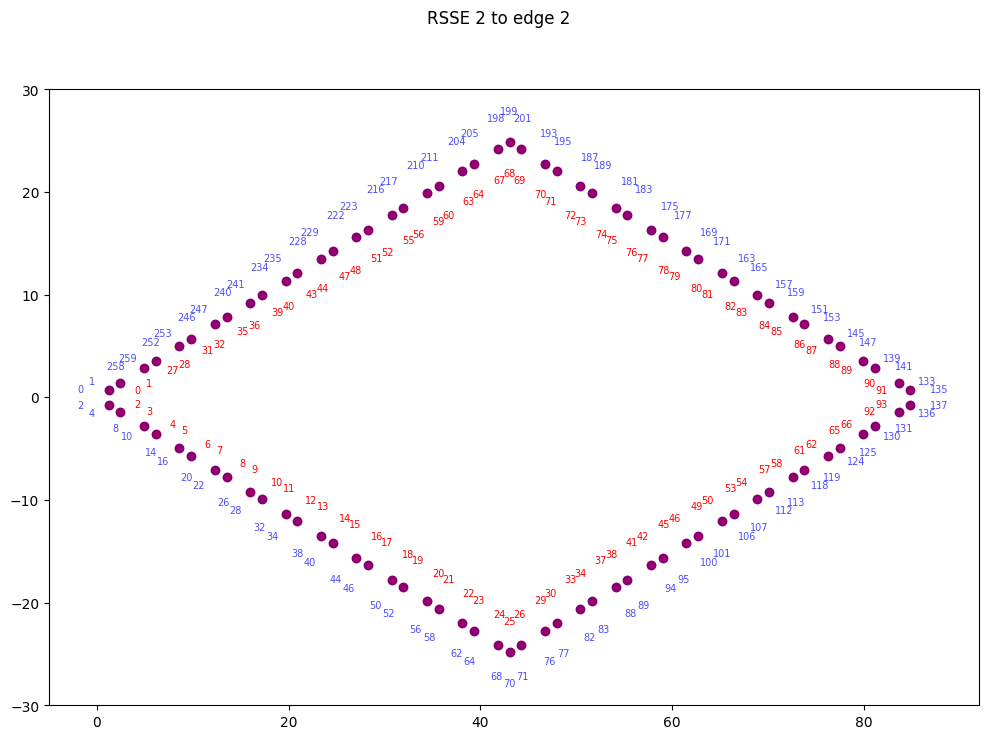

In [251]:
tol = 1e-4
rsse2_xyz = Ham_rs_elec2.xyz


tree = cKDTree(g2edge.xyz)
dd, ii = tree.query(rsse2_xyz, k=1)
fig, ax = plt.subplots(figsize=(12,8))

ax.scatter(*rsse2_xyz.T[:2], c='r')
ax.scatter(*g2edge.xyz[ii, :2].T, alpha=0.4, c='b')

# Compute structure center in xy
center = g2edge.center()[:2]

offset_scale = 3 # Å — tune this

for i, rsseidx in enumerate(ii):
    x_rsse, y_rsse, _ = rsse2_xyz[i]
    x_edge, y_edge, _ = g2edge.xyz[rsseidx]

    # Outward unit normal: direction from center to atom
    outward = np.array([x_edge, y_edge]) - center
    outward /= np.linalg.norm(outward)  # unit vector

    # RSSE index: nudge inward (toward center)
    dx_in, dy_in = -outward * offset_scale
    ax.text(x_rsse + dx_in, y_rsse + dy_in, i, 
            ha="center", va="center", color='r', fontsize=7)

    # Edge index: nudge outward (away from center)
    dx_out, dy_out = outward * offset_scale
    ax.text(x_edge + dx_out, y_edge + dy_out, rsseidx,
            ha="center", va="center", color='b', fontsize=7, alpha=0.7)


ax.set(xlim=(-5, 92),
       ylim=(-30, 30),
    )
    
fig.suptitle("RSSE 2 to edge 2")

In [257]:
def rsse_to_edge(rsse, edge):
    if not hasattr(rsse, 'xyz'):
        raise AttributeError("`rsse` must have .xyz attribute")
    if not hasattr(edge, 'xyz'):
        raise AttributeError("`edge` must have .xyz attribute")
        
    # the coords available to target
    tree = cKDTree(edge.xyz)
    
    # what to match
    dd, ii = tree.query(rsse.xyz, k=1)
    
    return ii

edge1_to_rsse1 = {int(edgeidx):int(rsseidx) for rsseidx, edgeidx  in enumerate(rsse_to_edge(Ham_rs_elec1, g1edge))}
rsse2_to_edge2 = {int(rsseidx):int(edgeidx) for rsseidx, edgeidx in enumerate(rsse_to_edge(Ham_rs_elec2, g2edge))}

# convert the g2edge index to the g1edge index
g2edge_to_g1edge = {int(g2idx):int(g1idx) for g2idx, g1idx in enumerate(extrapolate(g1edge, g2edge, N1, N2, Ham0.na, NC=1))}

In [258]:
test = extrapolate(g1edge, g2edge, N1, N2, Ham0.na, NC=1)
print(np.sort(test), test.shape)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  12  12  13  13  13
  14  14  14  15  15  15  16  16  16  17  17  17  18  18  19  19  20  20
  21  21  22  22  23  23  24  24  24  25  25  25  26  26  26  27  27  27
  28  28  28  29  29  29  30  31  32  33  34  35  36  37  38  39  40  41
  42  43  44  45  46  47  48  48  48  49  49  49  50  50  50  51  51  51
  52  52  52  53  53  53  54  54  55  55  56  56  57  57  58  58  59  59
  60  60  60  61  61  61  62  62  62  63  63  63  64  64  64  65  65  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  84  84  85  85  85  86  86  86  87  87  87  88  88  88  89  89  89
  90  90  91  91  92  92  93  93  94  94  95  95  96  96  96  97  97  97
  98  98  98  99  99  99 100 100 100 101 101 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 120 120 121 121 121
 122 122 122 123 123 123 124 124 124 125 125 125 126 126 127 127 128 128
 129 129 130 130 131 131 132 132 132 133 133 133 13

### example of mapping: 
> `ir2` --> `ie4` --> `ie1` --> `ir1`
> 3 --> 4 --> 4 --> 3
> 68 --> 199 --> 109 --> 38
> 51 --> 222 --> 120 --> 29

In [263]:
print("ir2 --> ie4 --> ie1 --> ir1")


ir2 = 51

ie2 = rsse2_to_edge2[ir2]
ie1 = g2edge_to_g1edge[ie2]
ir1 = edge1_to_rsse1[ie1]
print("{} --> {} --> {} --> {}".format(ir2, ie2, ie1, ir1))
# print(ir2)
# print(ie2)
# print(ie1)
# print(ir1)

ir2 --> ie4 --> ie1 --> ir1
51 --> 222 --> 120 --> 29


In [269]:
ir2 = 51
edge1_to_rsse1[g2edge_to_g1edge[rsse2_to_edge2[ir2]]]

29

In [283]:
def rsse_mapping(rsse1, rsse2, geom1, geom2, tiles1, tiles2, na=6, NC=1):
    edge1_to_rsse1 = {int(edgeidx):int(rsseidx) for rsseidx, edgeidx  in enumerate(rsse_to_edge(rsse1, geom1))}
    rsse2_to_edge2 = {int(rsseidx):int(edgeidx) for rsseidx, edgeidx in enumerate(rsse_to_edge(rsse2, geom2))}

    # convert the g2edge index to the g1edge index
    edge2_to_edge1 = {int(g2idx):int(g1idx) for g2idx, g1idx in enumerate(extrapolate(geom1, geom2, tiles1, tiles2, na=na, NC=NC))}
    return rsse2_to_edge2, edge2_to_edge1, edge1_to_rsse1



r2_to_e2, e2_to_e1, e1_to_r1 = rsse_mapping(Ham_rs_elec1, Ham_rs_elec2, g1edge, g2edge, N1, N2, Ham0.na, NC=1)

converter = lambda ir2 : e1_to_r1[e2_to_e1[r2_to_e2[ir2]]]

## sort atoms so edge atoms are first elements

In [ ]:
Ham_rs_NN1 = rsse1.real_space_parent()
Ham_rs_NN2 = rsse2.real_space_parent()

all_indices_geom1 = np.arange(Ham_rs_NN1.na)
device_atoms1 = np.delete(all_indices_geom1, elec_idx1)
reordered_atoms1 = np.concat(elec_idx1, device_atoms1)

all_indices_geom2 = np.arange(Ham_rs_NN2.na)
device_atoms2 = np.delete(all_indices_geom2, elec_idx2)
reordered_atoms2 = np.concat(elec_idx2, device_atoms2)

Ham_rs_reordered1 = Ham_rs_NN1.sub(reordered_atoms1)
Ham_rs_reordered2 = Ham_rs_NN2.sub(reordered_atoms2)




54


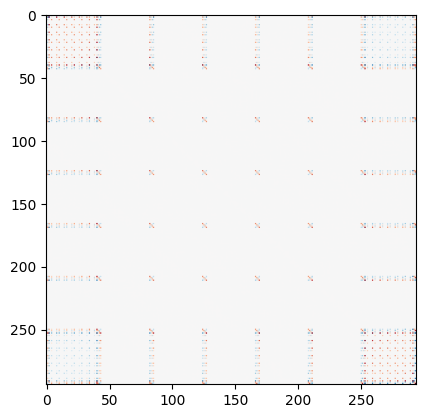

In [291]:
print(Ham_rs_elec1.na)
fig, ax = plt.subplots()

im = rsse1.self_energy(z).imag
vmax = np.abs(im.max())
vmin = -vmax
ax.imshow(im[:], cmap="RdBu", vmin=vmin, vmax=vmax)

array([  0,   1,   2,   4,   8,  10,  14,  16,  20,  22,  26,  28,  32,
        34,  38,  40,  41,  42,  43,  82,  83,  84,  85, 124, 125, 126,
       127, 166, 167, 168, 169, 208, 209, 210, 211, 250, 251, 252, 253,
       255, 259, 261, 265, 267, 271, 273, 277, 279, 283, 285, 289, 291,
       292, 293], dtype=int32)

In [294]:
im.shape

(294, 294)

In [ ]:
%%timeit
# break
rsse2.self_energy(z)

: 

In [ ]:
%%timeit 
# break
rsse1.self_energy(z)

SyntaxError: 'break' outside loop (<magic-timeit-stmt>, line 1)